## Import modul

In [1]:
!sudo pip install tensorflowjs

     |████████████████████████████████| 89 kB 3.9 MB/s eta 0:00:011
     |████████████████████████████████| 71.6 MB 58 kB/s s eta 0:00:01
     |████████████████████████████████| 16.8 MB 66.1 MB/s eta 0:00:01
     |████████████████████████████████| 479.6 MB 17 kB/s s eta 0:00:01
     |████████████████████████████████| 1.7 MB 59.7 MB/s eta 0:00:01
     |████████████████████████████████| 226 kB 60.3 MB/s eta 0:00:01
     |████████████████████████████████| 53 kB 1.2 MB/s  eta 0:00:01
     |████████████████████████████████| 1.3 MB 81.3 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 34.5 MB 56.8 MB/s eta 0:00:01
     |████████████████████████████████| 1.0 MB 62.2 MB/s eta 0:00:01
     |████████████████████████████████| 17.3 MB 61.0 MB/s eta 0:00:01
     |████████████████████████████████| 133 kB 57.0 MB/s eta 0:00:01
     |████████████████████████████████| 12

In [2]:
import os
import cv2
import shutil
import pathlib
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

## Load Dataset

In [3]:
# Path dataset
data_dir = "/kaggle/input/rice-image-dataset/Rice_Image_Dataset"
data_dir = pathlib.Path(data_dir)

In [4]:
# Mengambil gambar dari setiap kategori
categories = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
data_images = {}
data_labels = {}

In [5]:
# Assign label numerik untuk kategori dengan batasan 2500 gambar per kategori
for i, category in enumerate(categories):
    data_images[category] = list(data_dir.glob(f'{category}/*'))[:2500]  # Membatasi hingga 2500 gambar
    data_labels[category] = i

## Visualisasi jumlah dan persebaran data asli sebelum dibagi

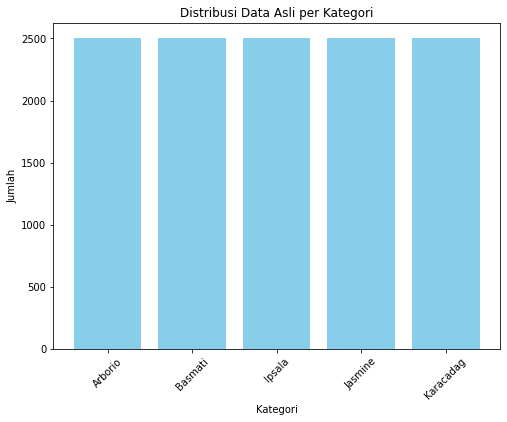

In [6]:
# Visualisasi jumlah dan persebaran data asli sebelum dibagi
data_distribution = []
for category in categories:
    data_distribution.append({'Kategori': category, 'Jumlah': len(data_images[category])})
data_distribution_df = pd.DataFrame(data_distribution)

plt.figure(figsize=(8, 6))
plt.bar(data_distribution_df['Kategori'], data_distribution_df['Jumlah'], color='skyblue')
plt.xlabel('Kategori')
plt.ylabel('Jumlah')
plt.title('Distribusi Data Asli per Kategori')
plt.xticks(rotation=45)
plt.show()

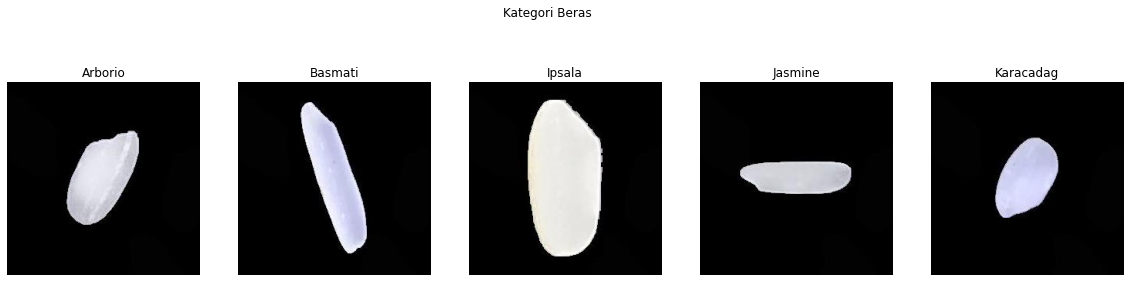

In [7]:
# Menampilkan contoh gambar dari setiap kategori
fig, ax = plt.subplots(ncols=5, figsize=(20, 5))
fig.suptitle('Kategori Beras')

for i, category in enumerate(categories):
    img_sample = cv2.imread(str(data_images[category][0]))
    ax[i].imshow(cv2.cvtColor(img_sample, cv2.COLOR_BGR2RGB))
    ax[i].set_title(category)
    ax[i].axis('off')
plt.show()

## Pengumpulan Data

In [8]:
# Mengumpulkan dataset
X_data, y_data = [], []
for label, images in data_images.items():
    for image in images:
        img = cv2.imread(str(image))  # Membaca gambar tanpa preprocessing
        img_resized = cv2.resize(img, (128, 128))  # Normalisasi ukuran gambar
        X_data.append(img_resized)
        y_data.append(data_labels[label])

In [9]:
# Konversi ke array numpy
X_data = np.array(X_data, dtype=np.float32) / 255.0
y_data = np.array(y_data)

In [10]:
# Membagi dataset menjadi training, validation, dan testing
X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

## Membuat Model dan Kompilasi

In [11]:
# Model CNN dengan arsitektur sederhana
model = keras.Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(len(categories), activation='softmax')
])

# Kompilasi model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


 ## Training Model

In [12]:
# Callback
callbacks = [
    ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=2, min_lr=1e-6)
]

# Training model with callbacks
epochs = 30
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/30
274/274 [==============================] - 11s 14ms/step - loss: 0.2210 - accuracy: 0.9219 - val_loss: 0.1070 - val_accuracy: 0.9643
Epoch 2/30
274/274 [==============================] - 3s 10ms/step - loss: 0.0959 - accuracy: 0.9653 - val_loss: 0.0807 - val_accuracy: 0.9707
Epoch 3/30
274/274 [==============================] - 3s 10ms/step - loss: 0.0741 - accuracy: 0.9725 - val_loss: 0.0724 - val_accuracy: 0.9749
Epoch 4/30
274/274 [==============================] - 3s 10ms/step - loss: 0.0585 - accuracy: 0.9790 - val_loss: 0.1313 - val_accuracy: 0.9605
Epoch 5/30
274/274 [==============================] - 3s 10ms/step - loss: 0.0473 - accuracy: 0.9817 - val_loss: 0.0765 - val_accuracy: 0.9755
Epoch 6/30
274/274 [==============================] - 3s 10ms/step - loss: 0.0184 - accuracy: 0.9936 - val_loss: 0.0559 - val_accuracy: 0.9808
Epoch 7/30
274/274 [==============================] - 3s 10ms/step - loss: 0.0120 - accuracy: 0.9961 - val_loss: 0.0561 - val_accuracy: 0.981

## Evaluasi Model

In [13]:
# Evaluasi model
model.evaluate(X_test, y_test)

59/59 [==============================] - 0s 5ms/step - loss: 0.0982 - accuracy: 0.9739


[0.09815073758363724, 0.9738666415214539]

## Visualisasi Hasil Training Model

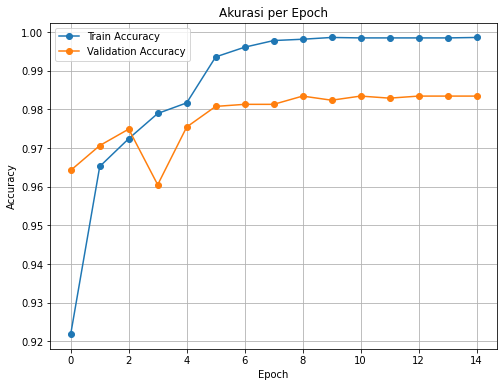

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Akurasi per Epoch')
plt.legend()
plt.grid()
plt.show()

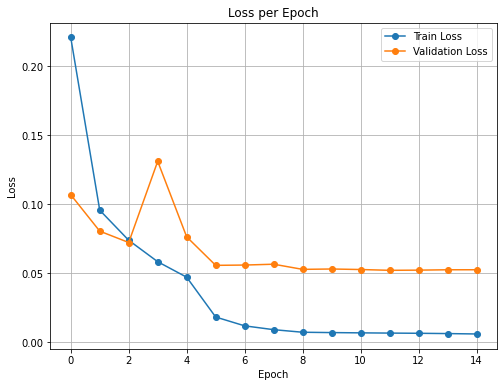

In [15]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()
plt.grid()
plt.show()

In [16]:
# Prediksi pada data uji
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Ambil kelas dengan probabilitas tertinggi

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=categories))

Classification Report:
              precision    recall  f1-score   support

     Arborio       0.95      0.97      0.96       363
     Basmati       0.98      0.98      0.98       374
      Ipsala       1.00      0.99      0.99       392
     Jasmine       0.97      0.97      0.97       367
   Karacadag       0.97      0.96      0.96       379

    accuracy                           0.97      1875
   macro avg       0.97      0.97      0.97      1875
weighted avg       0.97      0.97      0.97      1875



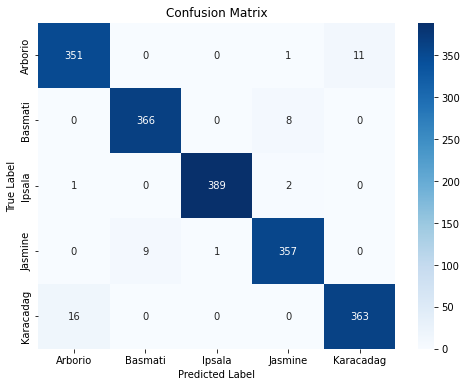

In [17]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Simpan Model dalam Berbagai Format

In [18]:
# Simpan model dalam format SavedModel
saved_model_path = "saved_model"
model.save(saved_model_path)

In [19]:
# Simpan model dalam format TF-Lite
tflite_model_path = "tflite/model.tflite"
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()
os.makedirs("tflite", exist_ok=True)
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

In [20]:
# Simpan label
with open("tflite/label.txt", "w") as f:
    f.write("\n".join(categories))

In [21]:
# Simpan model dalam format TFJS
os.system("mkdir -p tfjs_model")
os.system("tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model saved_model tfjs_model")

0

In [22]:
# Buat zip dari seluruh folder /kaggle/working/
shutil.make_archive("/kaggle/working/rice_models", 'zip', "/kaggle/working/")

'/kaggle/working/rice_models.zip'

## Melakukan Inference

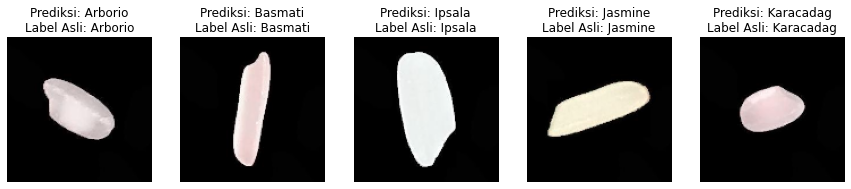

In [23]:
# Load model dari folder SavedModel
saved_model_path = "saved_model"
loaded_model = tf.keras.models.load_model(saved_model_path)

# Pilih satu gambar dari setiap kelas
unique_classes = set(y_test)  # Mendapatkan semua kelas unik
samples = []
true_labels = []

for cls in unique_classes:
    idx = np.where(y_test == cls)[0][0]  # Ambil indeks pertama dari setiap kelas
    samples.append(X_test[idx])
    true_labels.append(categories[cls])

samples = np.array(samples)

# Lakukan prediksi
predictions = loaded_model.predict(samples)
predicted_classes = [categories[np.argmax(pred)] for pred in predictions]

# Visualisasi hasil prediksi
fig, axes = plt.subplots(1, len(samples), figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(samples[i])
    ax.set_title(f"Prediksi: {predicted_classes[i]}\nLabel Asli: {true_labels[i]}")
    ax.axis('off')

plt.show()
